<a href="https://colab.research.google.com/github/Tory9696/Learn_algorithms/blob/main/AI_RGSU_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from tqdm.notebook import tqdm  # для прогресс-бара

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [7]:
# Трансформации для тренировки (с аугментацией)
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Трансформации для валидации / теста (без аугментации)
val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Загрузка данных
train_dataset = datasets.ImageFolder('/content/drive/MyDrive/ColabNotebooks/train', transform=train_transforms)
valid_dataset = datasets.ImageFolder('/content/drive/MyDrive/ColabNotebooks/valid', transform=val_test_transforms)
test_dataset  = datasets.ImageFolder('/content/drive/MyDrive/ColabNotebooks/test', transform=val_test_transforms)

# Классы
classes = train_dataset.classes
num_classes = len(classes)
print("Classes:", classes)
print("Train size:", len(train_dataset))
print("Valid size:", len(valid_dataset))
print("Test size:", len(test_dataset))

# DataLoader'ы
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Classes: ['Bus', 'Car', 'Truck', 'motorcycle']
Train size: 256
Valid size: 109
Test size: 357


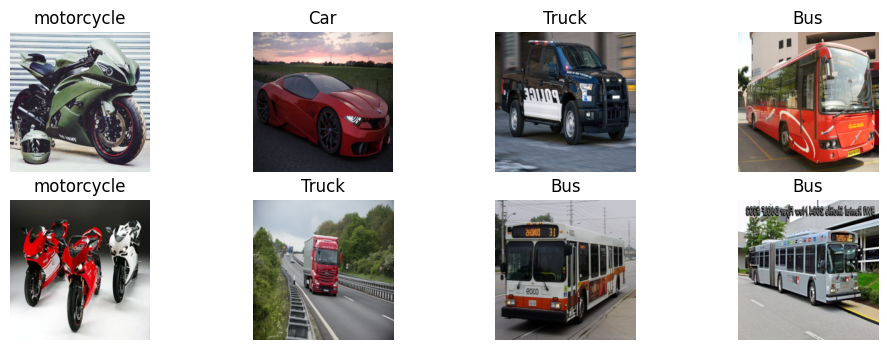

In [10]:
def imshow(img, title=None):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 4))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow(images[i], title=classes[labels[i]])
plt.show()

In [15]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in tqdm(train_loader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    return epoch_loss, epoch_acc, epoch_f1

def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs, device, model_name="Model"):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_f1 = evaluate(model, valid_loader, criterion, device)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        print(f"{model_name} - Epoch {epoch}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")
    return history

In [46]:
# Функция для оценки на тестовой выборке (по аналогии с evaluate, но только метрики)
def test_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return acc, f1

def show_predictions_balanced(model, test_loader, classes, device, num_per_class=2):
    model.eval()
    # Собираем предсказания для всех данных
    all_images = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_images.append(inputs.cpu())
            all_labels.append(labels.cpu())
            all_preds.append(preds.cpu())
    all_images = torch.cat(all_images)
    all_labels = torch.cat(all_labels)
    all_preds = torch.cat(all_preds)

    # Отбираем по num_per_class изображений каждого класса
    selected_idx = []
    for class_idx in range(len(classes)):
        idx = (all_labels == class_idx).nonzero(as_tuple=True)[0]
        selected_idx.extend(idx[:num_per_class].tolist())

    # Визуализируем
    plt.figure(figsize=(15, 5))
    plt.tight_layout(pad=4.0)
    for i, idx in enumerate(selected_idx):
        plt.subplot(2, num_per_class*len(classes)//2, i+1)
        img = all_images[idx].numpy().transpose(1,2,0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.title(f"True: {classes[all_labels[idx]]}\nPred: {classes[all_preds[idx]]}", fontsize=8)
        plt.axis('off')
    plt.show()

In [25]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 56 * 56, 256)  # 224 -> 112 -> 56 после двух пулингов
        self.fc2 = nn.Linear(256, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model_scratch = SimpleCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(model_scratch.parameters(), lr=0.001)

history_scratch = train_model(model_scratch, train_loader, valid_loader, criterion, optimizer_scratch, 15, device,  model_name="Scratch CNN")

Training:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Model - Epoch 1/15 | Train Loss: 10.4491 Acc: 0.2109 | Val Loss: 1.4635 Acc: 0.3211 F1: 0.1561


Training:   0%|          | 0/8 [00:00<?, ?it/s]

...

Model - Epoch 14/15 | Train Loss: 0.3749 Acc: 0.8867 | Val Loss: 1.3377 Acc: 0.5138 F1: 0.5218


Training:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Model - Epoch 15/15 | Train Loss: 0.3424 Acc: 0.8945 | Val Loss: 1.4230 Acc: 0.5046 F1: 0.5161


SimpleCNN - Test Accuracy: 0.8319, Test F1: 0.8334


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


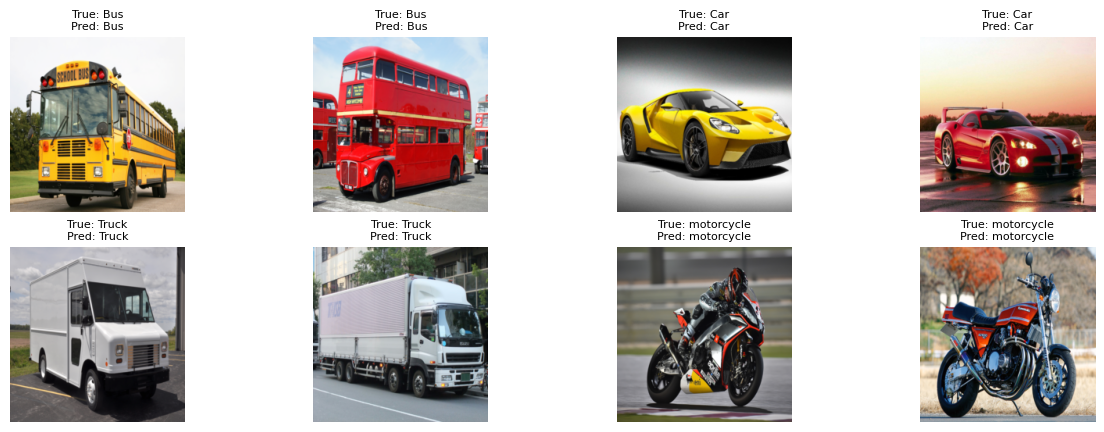

In [47]:
test_acc, test_f1 = test_model(model_scratch, test_loader, device)
print(f"SimpleCNN - Test Accuracy: {test_acc:.4f}, Test F1: {test_f1:.4f}")
show_predictions_balanced(model_scratch, test_loader, classes, device, num_per_class=2)

In [29]:
model_frozen = models.resnet18(pretrained=True)
# Заморозка всех слоёв
for param in model_frozen.parameters():
    param.requires_grad = False
# Замена последнего слоя
num_ftrs = model_frozen.fc.in_features
model_frozen.fc = nn.Linear(num_ftrs, num_classes)
model_frozen = model_frozen.to(device)

# Оптимизатор только для нового слоя
optimizer_frozen = optim.Adam(model_frozen.fc.parameters(), lr=0.001)

history_frozen = train_model(model_frozen, train_loader, valid_loader, criterion, optimizer_frozen, 15, device, model_name="Frozen ResNet")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 99.3MB/s]


Training:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

...

Frozen ResNet - Epoch 14/15 | Train Loss: 0.1639 Acc: 0.9766 | Val Loss: 0.1367 Acc: 0.9633 F1: 0.9632


Training:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Frozen ResNet - Epoch 15/15 | Train Loss: 0.1515 Acc: 0.9727 | Val Loss: 0.1292 Acc: 0.9908 F1: 0.9909


Frozen ResNet - Test Accuracy: 0.9860, Test F1: 0.9860


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


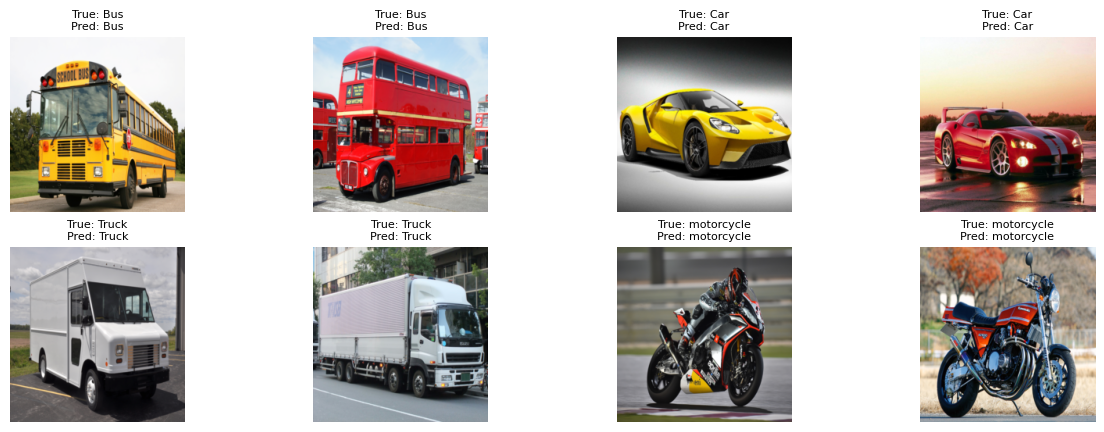

In [48]:
test_acc, test_f1 = test_model(model_frozen, test_loader, device)
print(f"Frozen ResNet - Test Accuracy: {test_acc:.4f}, Test F1: {test_f1:.4f}")
show_predictions_balanced(model_frozen, test_loader, classes, device, num_per_class=2)

In [30]:
model_finetune = models.resnet18(pretrained=True)
num_ftrs = model_finetune.fc.in_features
model_finetune.fc = nn.Linear(num_ftrs, num_classes)
model_finetune = model_finetune.to(device)

# Обучаем все слои, но с маленьким lr
optimizer_finetune = optim.Adam(model_finetune.parameters(), lr=1e-4)

history_finetune = train_model(model_finetune, train_loader, valid_loader, criterion,
                               optimizer_finetune, 15, device, model_name="Fine-tuned ResNet")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Training:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Fine-tuned ResNet - Epoch 1/15 | Train Loss: 0.8216 Acc: 0.6328 | Val Loss: 0.1805 Acc: 0.9725 F1: 0.9720


...

Fine-tuned ResNet - Epoch 14/15 | Train Loss: 0.0020 Acc: 1.0000 | Val Loss: 0.0402 Acc: 0.9817 F1: 0.9821


Training:   0%|          | 0/8 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Fine-tuned ResNet - Epoch 15/15 | Train Loss: 0.0031 Acc: 1.0000 | Val Loss: 0.0405 Acc: 0.9817 F1: 0.9821


Fine-tuned ResNet - Test Accuracy: 0.9944, Test F1: 0.9944


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


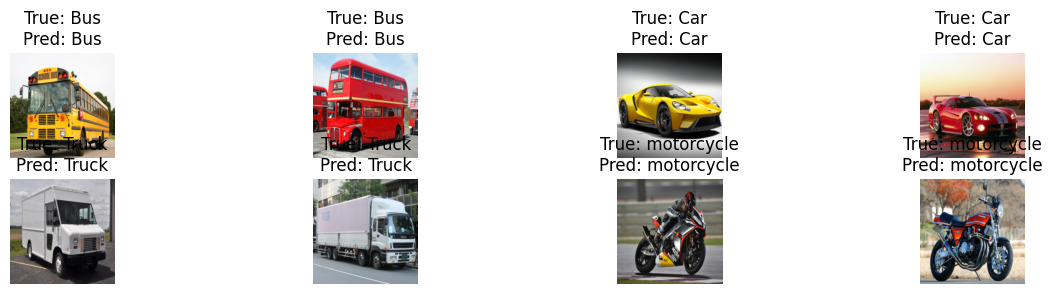

In [41]:
test_acc, test_f1 = test_model(model_finetune, test_loader, device)
print(f"Fine-tuned ResNet - Test Accuracy: {test_acc:.4f}, Test F1: {test_f1:.4f}")
show_predictions_balanced(model_finetune, test_loader, classes, device, num_per_class=2)

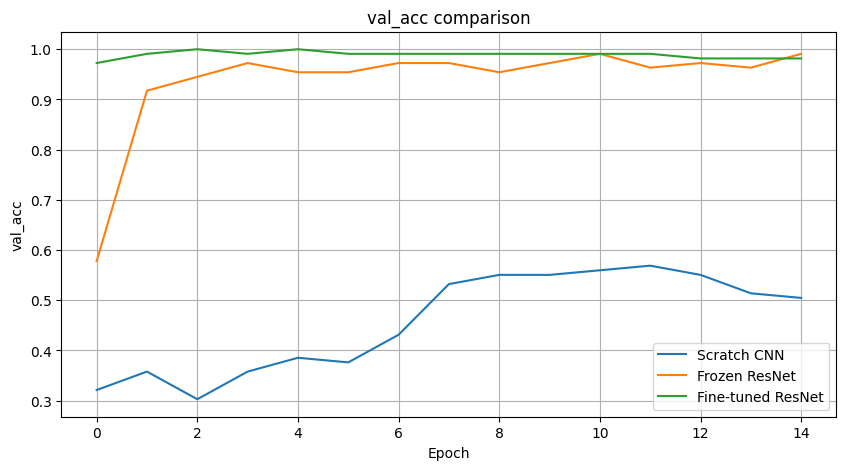

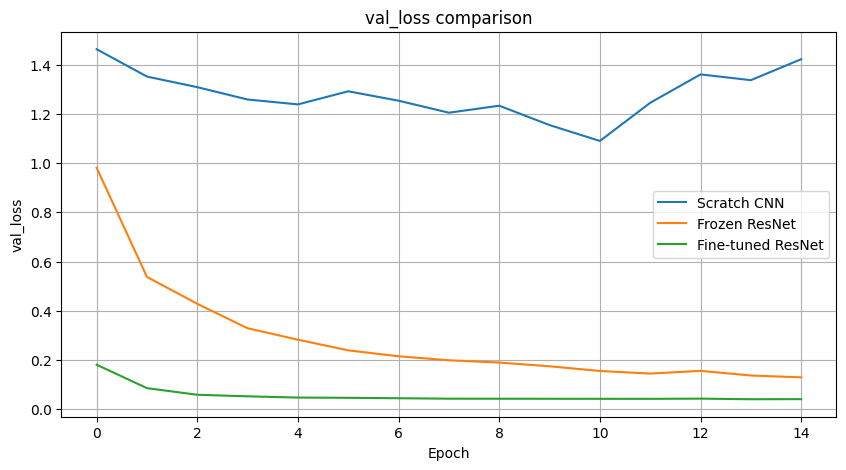

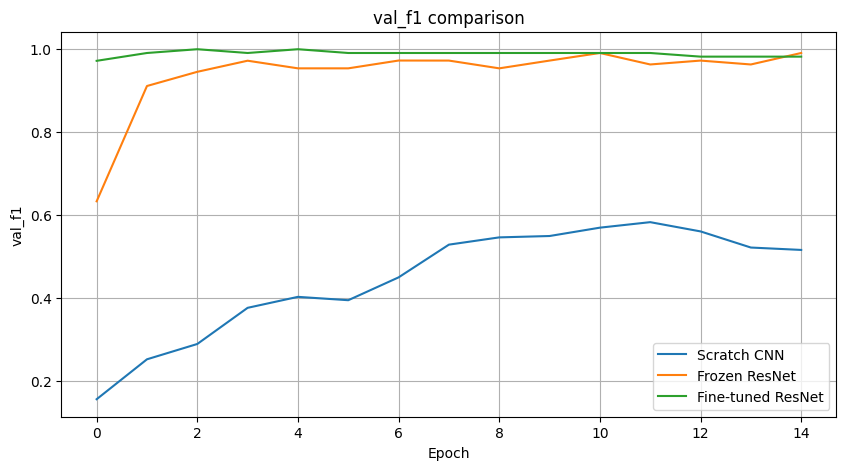

Scratch CNN:


Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Test Accuracy: 0.8319, F1: 0.8334
Frozen ResNet:


Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

...

Test Accuracy: 0.9860, F1: 0.9860
Fine-tuned ResNet:


Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Test Accuracy: 0.9944, F1: 0.9944


(0.9943977591036415, 0.9944230950714764)

In [31]:
def plot_history(histories, labels, metric='val_acc'):
    plt.figure(figsize=(10,5))
    for hist, label in zip(histories, labels):
        plt.plot(hist[metric], label=label)
    plt.title(f'{metric} comparison')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

histories = [history_scratch, history_frozen, history_finetune]
labels = ['Scratch CNN', 'Frozen ResNet', 'Fine-tuned ResNet']
plot_history(histories, labels, 'val_acc')
plot_history(histories, labels, 'val_loss')
plot_history(histories, labels, 'val_f1')

# Оценка на тестовой выборке
def test_model(model, test_loader, device):
    _, acc, f1 = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)
    print(f"Test Accuracy: {acc:.4f}, F1: {f1:.4f}")
    return acc, f1

print("Scratch CNN:")
test_model(model_scratch, test_loader, device)
print("Frozen ResNet:")
test_model(model_frozen, test_loader, device)
print("Fine-tuned ResNet:")
test_model(model_finetune, test_loader, device)